1.Detect cracks in metallic/ceramic surfaces using classical image techniques

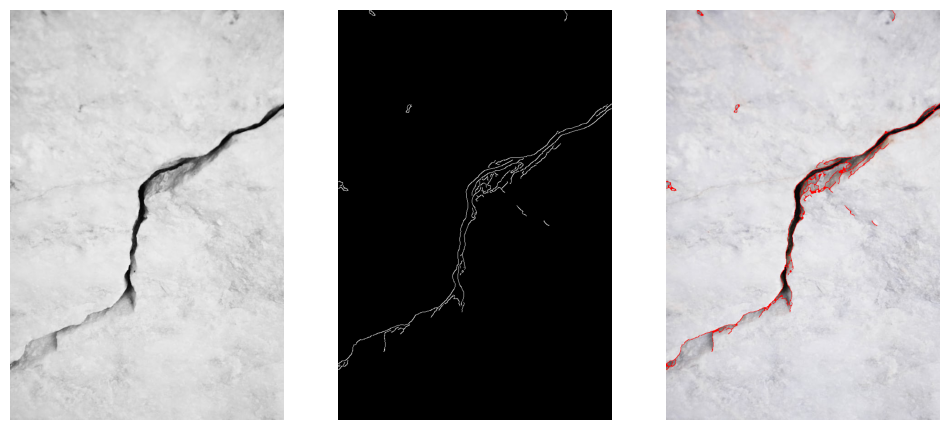

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/premium_photo-1669865741911-fdc00c7c3859.jpg"

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)
kernel = np.ones((3,3), np.uint8)
cracks = cv2.dilate(edges, kernel, iterations=1)
cracks = cv2.erode(cracks, kernel, iterations=1)
overlay = img.copy()
overlay[cracks > 0] = (0, 0, 255)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(edges, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()


2.Implement crack detection using ResNet/U-Net on a crack image dataset

In [ ]:
# Install dependencies
!pip install kaggle ultralytics tensorflow opencv-python matplotlib scikit-image --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_shape=(128, 128, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

unet = unet_model()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │    131,200 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# TRAIN U-NET WITH THRESHOLDED MASKS (FINAL)
# =========================================================
import os, cv2, glob
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

IMAGE_DIR = "/content/crackforest/Images/"
MASK_DIR  = "/content/crackforest/Masks/"

IMG_SIZE = 128
images, masks = [], []

# Load image paths
image_paths = sorted(glob.glob(IMAGE_DIR + "/*.jpg"))
mask_paths  = sorted(glob.glob(MASK_DIR + "/*.png") + glob.glob(MASK_DIR + "/*.PNG"))

print("Found images:", len(image_paths))
print("Found masks :", len(mask_paths))

for img_path, mask_path in zip(image_paths, mask_paths):

    # ----- Load image -----
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # ----- Load mask -----
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    # ----- THRESHOLD MASK -----
    # Everything > 25 becomes white (1), else black (0)
    _, mask = cv2.threshold(mask, 25, 255, cv2.THRESH_BINARY)

    mask = mask / 255.0
    mask = np.expand_dims(mask, -1)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks  = np.array(masks)

print("Loaded images array:", images.shape)
print("Loaded masks array :", masks.shape)

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

# Train existing U-Net model
unet.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

unet.save("unet_crackforest.h5")
print("Training complete.")


Found images: 118
Found masks : 118
Loaded images array: (118, 128, 128, 3)
Loaded masks array : (118, 128, 128, 1)
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.9776 - loss: 0.0977 - val_accuracy: 0.9772 - val_loss: 0.0965
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9791 - loss: 0.0910 - val_accuracy: 0.9772 - val_loss: 0.0942
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9774 - loss: 0.0943 - val_accuracy: 0.9772 - val_loss: 0.0899
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9810 - loss: 0.0777 - val_accuracy: 0.9772 - val_loss: 0.0856
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9797 - loss: 0.0796 - val_accuracy: 0.9772 - val_loss: 0.0804
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9791 - loss: 0.0781 - val_accuracy: 0.9772 - val_loss: 0.0761
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9795 - loss: 0.0707 - val_accuracy: 0.9773 - val_loss: 

Training complete.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


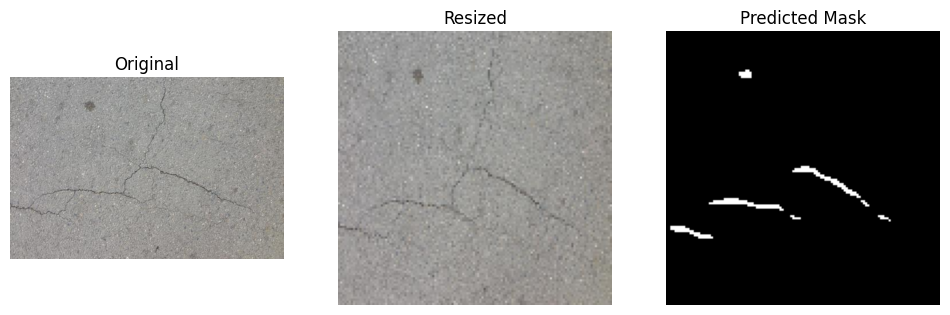

In [ ]:
# =========================================================
# TESTING / PREDICTION VIEW
# =========================================================
import matplotlib.pyplot as plt
import numpy as np
import cv2
import glob
from tensorflow.keras.models import load_model

model = load_model("unet_crackforest.h5", compile=False)

IMG_SIZE = 128
IMAGE_DIR = "/content/crackforest/Images/"

# Pick random test image
test_img_path = np.random.choice(glob.glob(IMAGE_DIR + "/*.jpg"))

img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)) / 255.0

inp = np.expand_dims(img_resized, 0)
pred = model.predict(inp)[0]
pred_mask = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Resized"); plt.imshow(img_resized); plt.axis("off")
plt.subplot(1,3,3); plt.title("Predicted Mask"); plt.imshow(pred_mask.squeeze(), cmap="gray"); plt.axis("off")
plt.show()


3.Classify a crack segmentation task into calibrated width measurements and severity
classes (narrow/medium/wide).

Mean width (mm): 3.410757914568304
Max width (mm): 8.661454843154239
Severity: Wide


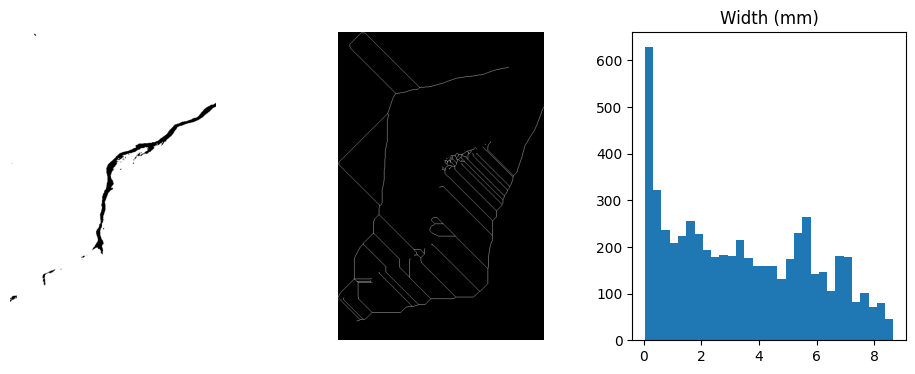

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt

mask_path = "/content/premium_photo-1669865741911-fdc00c7c3859.jpg"
pixel_mm = 0.02

mask = cv2.imread(mask_path, 0)
mask = (mask > 127).astype(np.uint8)

skel = skeletonize(mask).astype(np.uint8)
dist = distance_transform_edt(mask)

width_pixels = dist[skel == 1] * 2
width_mm = width_pixels * pixel_mm

mean_width = np.mean(width_mm)
max_width = np.max(width_mm)

if mean_width < 0.3:
    severity = "Narrow"
elif mean_width < 1.0:
    severity = "Medium"
else:
    severity = "Wide"

print("Mean width (mm):", mean_width)
print("Max width (mm):", max_width)
print("Severity:", severity)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(skel, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.hist(width_mm, bins=30); plt.title("Width (mm)")
plt.show()


4.Detect the weld seam and flag discontinuities under noisy, site-like conditions.

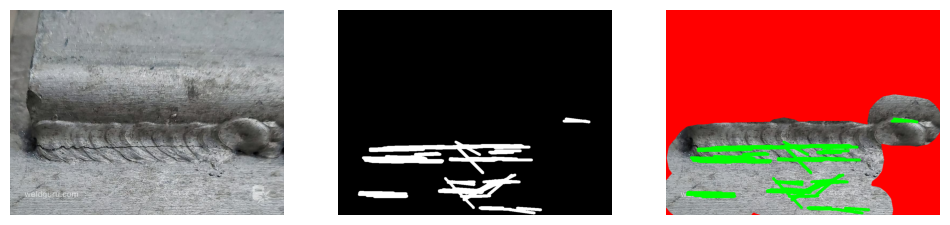

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/weld-longitudinal-crack-example-1024x769.jpg"

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.bilateralFilter(gray, 9, 75, 75)
edges = cv2.Canny(blur, 50, 150)

kernel = np.ones((5,5),np.uint8)
edges_clean = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

lines = cv2.HoughLinesP(edges_clean, 1, np.pi/180, threshold=80, minLineLength=80, maxLineGap=20)
seam_mask = np.zeros_like(gray)
if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = l[0]
        cv2.line(seam_mask, (x1,y1), (x2,y2), 255, 10)

dist = cv2.distanceTransform(255-seam_mask, cv2.DIST_L2, 5)
dist_norm = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
th = cv2.threshold(dist_norm, 40, 255, cv2.THRESH_BINARY)[1]
th = cv2.medianBlur(th, 7)

defect_mask = cv2.bitwise_and(th, th, mask=(255-seam_mask))

overlay = img.copy()
overlay[defect_mask>0] = (0,0,255)
overlay[seam_mask>0] = (0,255,0)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(seam_mask, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()


5. Implement PCB inspection via template matching

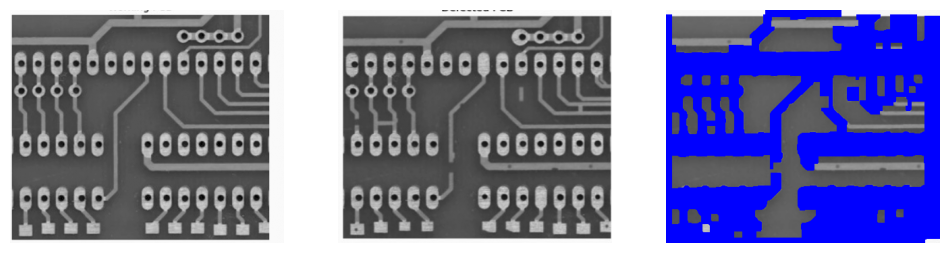

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref_path = "/content/Screenshot 2025-11-14 204604.png"
test_path = "/content/Screenshot 2025-11-14 204620.png"

ref = cv2.imread(ref_path, 0)
test = cv2.imread(test_path, 0)

fx = ref.shape[1] / test.shape[1]
fy = ref.shape[0] / test.shape[0]
test = cv2.resize(test, None, fx=fx, fy=fy)

diff = cv2.absdiff(ref, test)
blur = cv2.GaussianBlur(diff, (5,5), 0)
_, th = cv2.threshold(blur, 30, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

overlay = cv2.cvtColor(test, cv2.COLOR_GRAY2BGR)
overlay[clean>0] = (0,0,255)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(ref, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(test, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis('off')
plt.show()


6.Precisely localize PCB defects via golden template alignment and adaptive keypoints.

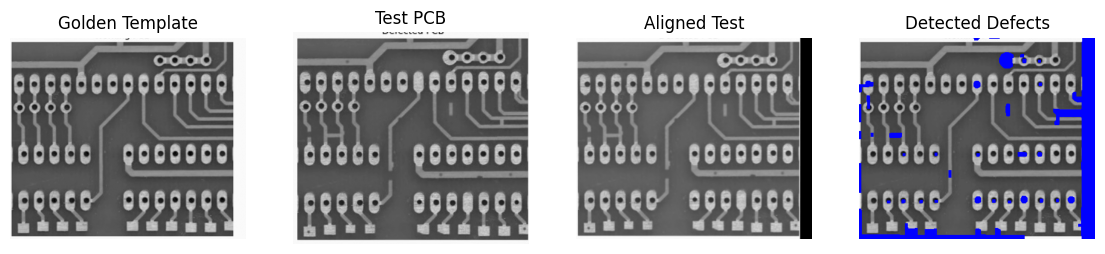

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ref_path = "/content/Screenshot 2025-11-14 204604.png"
test_path = "/content/Screenshot 2025-11-14 204620.png"

ref = cv2.imread(ref_path, 0)
test = cv2.imread(test_path, 0)

orb = cv2.ORB_create(5000)
kp1, des1 = orb.detectAndCompute(ref, None)
kp2, des2 = orb.detectAndCompute(test, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

aligned = cv2.warpPerspective(test, H, (ref.shape[1], ref.shape[0]))

diff = cv2.absdiff(ref, aligned)
blur = cv2.GaussianBlur(diff, (7,7), 0)
_, th = cv2.threshold(blur, 25, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

overlay = cv2.cvtColor(ref, cv2.COLOR_GRAY2BGR)
overlay[clean>0] = (0,0,255)

plt.figure(figsize=(14,4))
plt.subplot(1,4,1); plt.imshow(ref, cmap='gray'); plt.title("Golden Template"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(test, cmap='gray'); plt.title("Test PCB"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(aligned, cmap='gray'); plt.title("Aligned Test"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(overlay); plt.title("Detected Defects"); plt.axis('off')
plt.show()


7.Segment and classify surface defects using rule-based pipelines

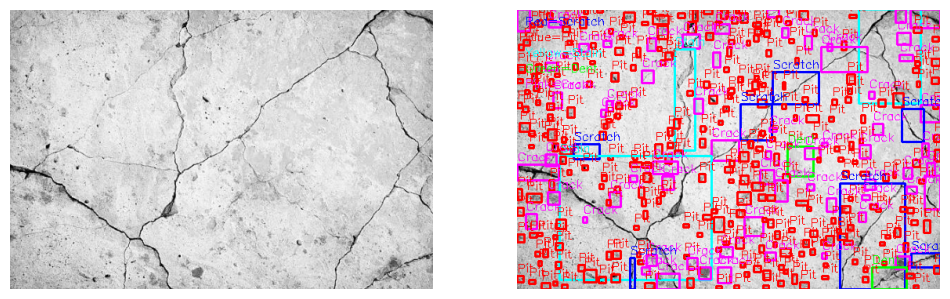

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

img_path = "/content/Screenshot 2025-11-14 205347.png"
img = cv2.imread(img_path, 0)
blur = cv2.GaussianBlur(img, (5,5), 0)
th = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,41,5)
kernel = np.ones((3,3),np.uint8)
mask = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel,2)

lbl = label(mask)
overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for r in regionprops(lbl):
    y1,x1,y2,x2 = r.bbox
    area = r.area
    per = r.perimeter
    aspect = r.major_axis_length / (r.minor_axis_length+1e-6)
    solidity = r.solidity
    if area < 20: continue
    if aspect > 6:
        cls = "Scratch"; color = (0,0,255)
    elif area < 150 and solidity>0.8:
        cls = "Pit"; color = (255,0,0)
    elif area > 500 and solidity<0.6:
        cls = "Stain"; color = (0,255,255)
    elif area > 300 and aspect < 3:
        cls = "Dent"; color = (0,255,0)
    else:
        cls = "Crack"; color = (255,0,255)
    cv2.rectangle(overlay,(x1,y1),(x2,y2),color,2)
    cv2.putText(overlay,cls,(x1,y1-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,color,1)

cv2.putText(overlay,"Red=Scratch",(10,20),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1)
cv2.putText(overlay,"Blue=Pit",(10,40),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),1)
cv2.putText(overlay,"Yellow=Stain",(10,60),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),1)
cv2.putText(overlay,"Green=Dent",(10,80),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
cv2.putText(overlay,"Pink=Crack",(10,100),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,255),1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img,cmap='gray'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(overlay); plt.axis('off')
plt.show()


8.Analyze IR thermal maps to detect abnormal heating zones

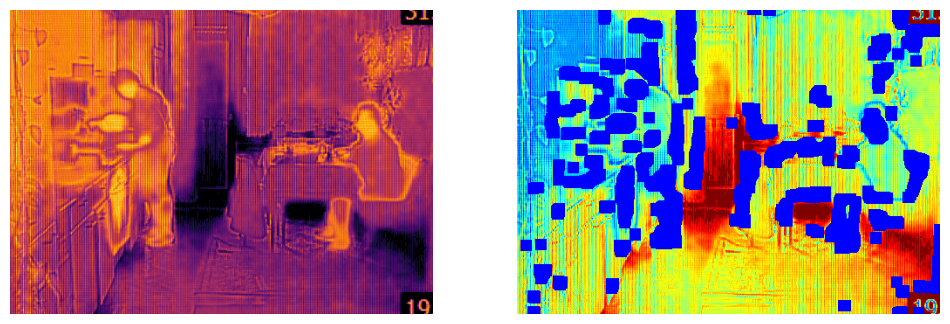

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/Screenshot 2025-11-14 205924.png"
img = cv2.imread(img_path, 0)
img_float = cv2.normalize(img.astype('float32'), None, 0, 1, cv2.NORM_MINMAX)

blur = cv2.GaussianBlur(img_float, (11,11), 0)
th = cv2.adaptiveThreshold((blur*255).astype('uint8'),255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,51,-5)

kernel = np.ones((7,7),np.uint8)
mask = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel,2)
mask = cv2.dilate(mask, kernel,2)

overlay = cv2.applyColorMap((img_float*255).astype('uint8'), cv2.COLORMAP_JET)
overlay[mask>0] = (0,0,255)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_float, cmap='inferno'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(overlay); plt.axis('off')
plt.show()


9.Using visual analytics, detect thermal anomalies in images with annotated hot spots.

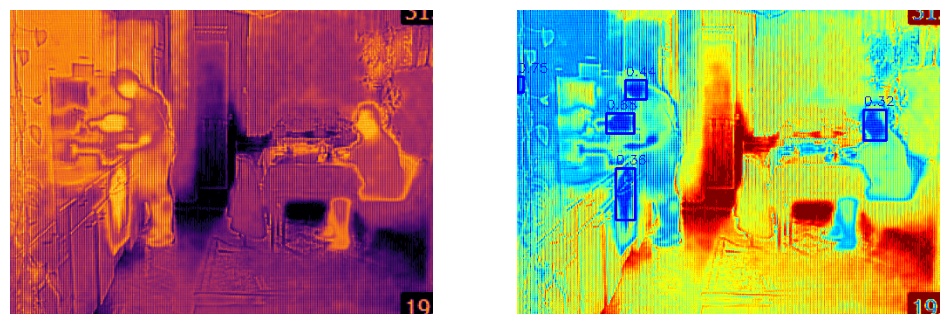

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

img_path = "/content/Screenshot 2025-11-14 205924.png"
img = cv2.imread(img_path, 0)

img_norm = cv2.normalize(img.astype("float32"), None, 0, 1, cv2.NORM_MINMAX)
blur = cv2.GaussianBlur(img_norm, (9,9), 0)
val = np.percentile(blur, 98)
_, th = cv2.threshold(blur, val, 1, cv2.THRESH_BINARY)

th = (th*255).astype("uint8")
kernel = np.ones((7,7), np.uint8)
mask = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, 2)
mask = cv2.dilate(mask, kernel, 2)

lbl = label(mask)
overlay = cv2.applyColorMap((img_norm*255).astype("uint8"), cv2.COLORMAP_JET)

h, w = img_norm.shape

for r in regionprops(lbl):
    y1, x1, y2, x2 = r.bbox
    cx, cy = r.centroid

    cy = min(max(int(cy), 0), h-1)
    cx = min(max(int(cx), 0), w-1)

    peak = img_norm[cy, cx]
    if peak < 0.2: continue

    cv2.rectangle(overlay, (x1,y1), (x2,y2), (0,0,255), 2)
    cv2.putText(overlay, f"{peak:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_norm, cmap='inferno'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(overlay); plt.axis('off')
plt.show()


10.Capture depth maps using stereo cameras or structured light and detect surface dents
and depth variations.


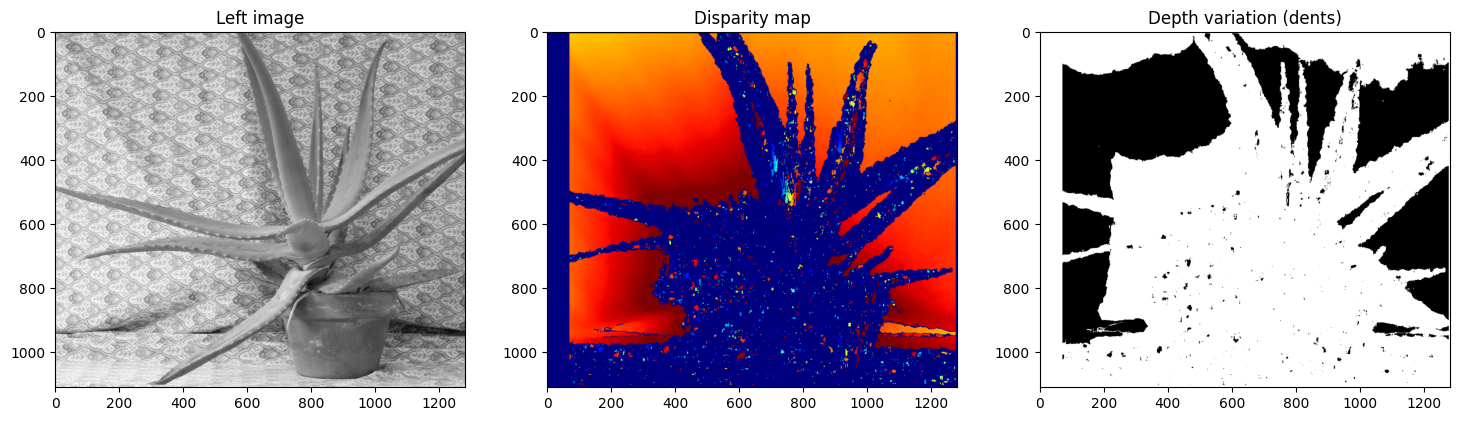

In [6]:
import cv2, numpy as np, matplotlib.pyplot as plt
import urllib.request

left_url  = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeL.jpg"
right_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeR.jpg"

urllib.request.urlretrieve(left_url, "left.jpg")
urllib.request.urlretrieve(right_url, "right.jpg")

imgL = cv2.imread("left.jpg", cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread("right.jpg", cv2.IMREAD_GRAYSCALE)

stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disparity = stereo.compute(imgL, imgR).astype(np.float32) / 16.0

disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

median_disp = np.median(disparity[np.where(disparity>0)])
depth_diff = np.abs(disparity - median_disp)
dents_mask = (depth_diff > 5).astype(np.uint8) * 255

plt.figure(figsize=(18,6))
plt.subplot(1,3,1); plt.title("Left image");    plt.imshow(imgL, cmap='gray')
plt.subplot(1,3,2); plt.title("Disparity map"); plt.imshow(disp_vis, cmap='jet')
plt.subplot(1,3,3); plt.title("Depth variation (dents)"); plt.imshow(dents_mask, cmap='gray')
plt.show()
